In [ ]:
#Start

# !/usr/bin/env python
# coding: utf-8

# Importing Pandas Library as variable pd
import pandas as pd

# Importing necessary libraries
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Impoirting the dataset from an excel file
df = pd.read_excel("../data/Health Insurance Dataset.xlsx")

In [3]:
# Displaying the columns and the first 10 rows of the dataset
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.head(10))
print(df.describe())

(1348, 9)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'Level',
       'score'],
      dtype='object')
age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges      object
Level        object
score       float64
dtype: object
    age     sex     bmi  children smoker     region      charges Level  score
0  19.0  female  27.900       0.0    yes  southwest    16884.924     B   72.0
1  18.0    male  33.770       1.0     no  southeast    1725.5523     C   69.0
2  28.0    male  33.000       3.0     no  southeast     4449.462     B   90.0
3  33.0    male  22.705       0.0     no  northwest  21984.47061     A   47.0
4  32.0    male  28.880       0.0     no  northwest    3866.8552     C   76.0
5  31.0  female  25.740       0.0     no  southeast    3756.6216     B   71.0
6  46.0  female  33.440       1.0     no  southeast    8240.5896     B   88.0
7  37.0  female  27.740       3.0     no  northwest  

In [4]:
#Data Cleaning
#Checking for missing values
print(df.isnull().sum())

age         10
sex          6
bmi          6
children     8
smoker      10
region       3
charges      3
Level       10
score       10
dtype: int64


In [5]:
# Dropping the missing values
df = df.dropna()

In [6]:
# Checking for duplicates
print(df.duplicated().sum())

0


In [7]:
#Checking for unique values
print(df.shape[0])
print(df.nunique())

1338
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
Level          5
score         81
dtype: int64


In [8]:
# Checking for unique values in each column
for column in df.columns:
    print(f"Unique values in {column}: {df[column].unique()}")

Unique values in age: [19. 18. 28. 33. 32. 31. 46. 37. 60. 25. 62. 23. 56. 27. 52. 30. 34. 59.
 63. 55. 22. 26. 35. 24. 41. 38. 36. 21. 48. 40. 58. 53. 43. 64. 20. 61.
 44. 57. 29. 45. 54. 49. 47. 51. 42. 50. 39.]
Unique values in sex: ['female' 'male']
Unique values in bmi: [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.7

In [9]:
# Converting charges to a float value

df['charges'] = df['charges'].astype(float)

(df['charges'].sample(10))


719     12231.61360
300      6746.74250
390     10736.87075
378     16455.70785
197      8516.82900
179      8538.28845
746     11737.84884
492      2196.47320
1144     9630.39700
1116     9222.40260
Name: charges, dtype: float64

In [10]:
# Ensuring the data will now allow for mathematical operations, and display that it has been converted to a float
print(df['charges'].sample(10).sum())

197104.9988


In [11]:
# Making sure the data conversion didn't change the entries to null
print(df.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
Level       0
score       0
dtype: int64


In [12]:
df.describe()

,age,bmi,children,charges,score
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,65.967115
std,14.049960,6.098187,1.205493,12110.011237,15.235684
min,18.000000,15.960000,0.000000,1121.873900,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,56.250000
50%,39.000000,30.400000,1.000000,9382.033000,66.000000
75%,51.000000,34.693750,2.000000,16639.912515,77.000000
max,64.000000,53.130000,5.000000,63770.428010,100.000000


In [13]:
# Score shouldn't be 0 so we will filter by IQR

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe to remove outliers
df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df.describe()

,age,bmi,children,charges,score
count,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000
mean,39.243223,30.647154,1.091867,13265.954625,66.347892
std,14.056899,6.105243,1.206236,12092.705960,14.624547
min,18.000000,15.960000,0.000000,1121.873900,26.000000
25%,27.000000,26.272500,0.000000,4746.875675,57.000000
50%,39.000000,30.305000,1.000000,9388.753650,66.000000
75%,51.000000,34.681250,2.000000,16604.302645,77.000000
max,64.000000,53.130000,5.000000,63770.428010,100.000000


In [14]:
# Calculating relative frequencies in percentages
relative_frequencies = {}
columns_to_check = ['sex', 'smoker', 'region', 'Level']

for column in columns_to_check:
    relative_frequencies[column] = df[column].value_counts(normalize=True).mul(100).round(2)

# Displaying the relative frequencies in percentages (sorted)
for column, frequencies in relative_frequencies.items():
    print(f"Relative frequencies for {column} (in %):\n{frequencies}\n")


Relative frequencies for sex (in %):
sex
male      50.45
female    49.55
Name: proportion, dtype: float64

Relative frequencies for smoker (in %):
smoker
no     79.52
yes    20.48
Name: proportion, dtype: float64

Relative frequencies for region (in %):
region
southeast    27.26
southwest    24.40
northwest    24.17
northeast    24.17
Name: proportion, dtype: float64

Relative frequencies for Level (in %):
Level
C    31.85
D    26.20
B    19.43
E    14.08
A     8.43
Name: proportion, dtype: float64



In [15]:
# import seaborn and matplotlib for visualizations
import seaborn as sns
import matplotlib.pyplot as plt

#### Univariate

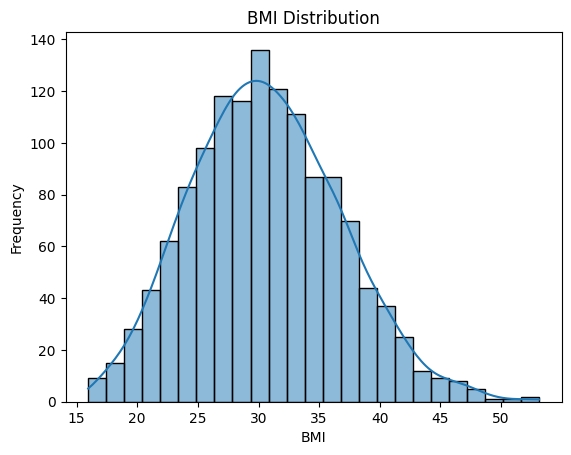

In [16]:
# Visualizing the distribution of BMI
sns.histplot(df['bmi'], kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

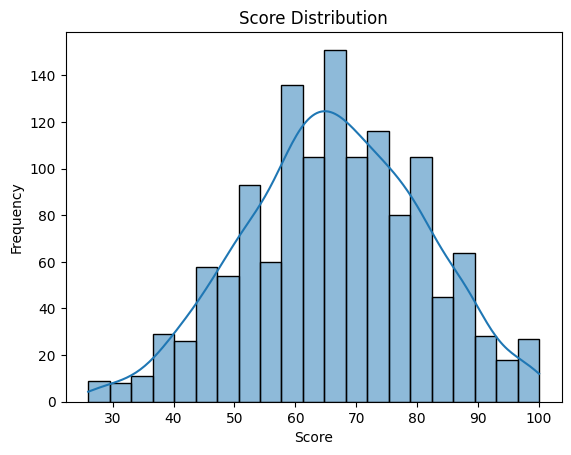

In [17]:
# Visualizing the distribution of score
sns.histplot(df['score'], kde=True)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

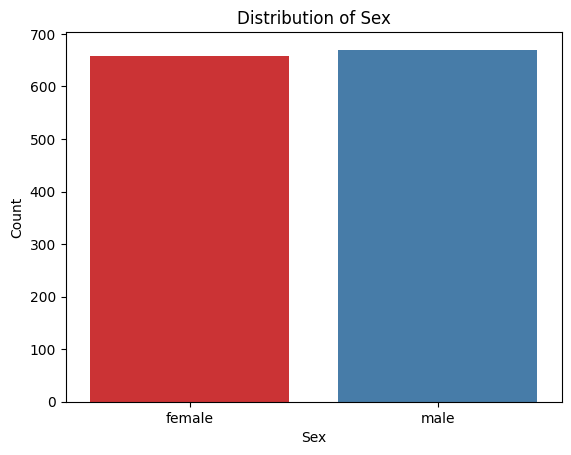

In [18]:
# Visualizing the distribution of charges
sns.countplot(x='sex', hue='sex', data=df, palette='Set1', legend=False)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

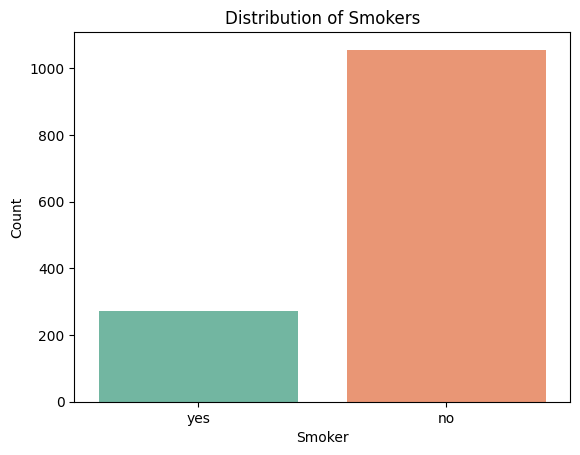

In [19]:
# Visualizing the distribution of smokers in the dataset
sns.countplot(x='smoker', hue='smoker', data=df, palette='Set2', legend=False)
plt.title('Distribution of Smokers')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

#### Bivariate


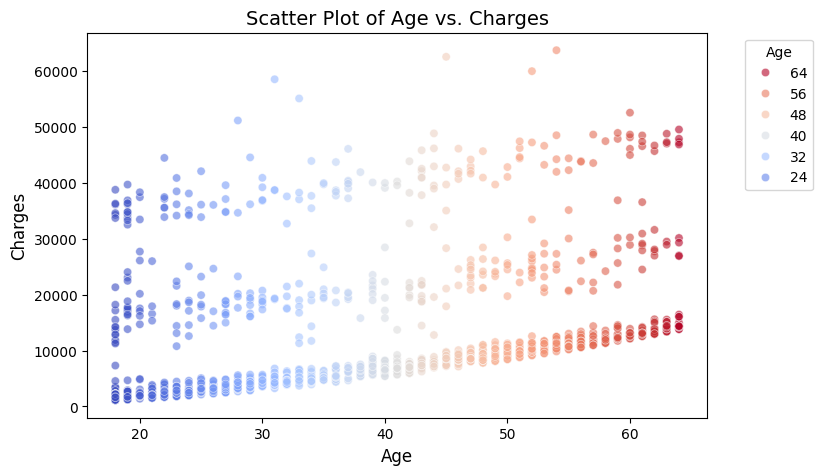

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="age", palette="coolwarm", alpha=0.6)

# Titles and Labels
plt.title("Scatter Plot of Age vs. Charges", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Charges", fontsize=12)

# Adjust legend placement
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title="Age", bbox_to_anchor=(1.05, 1), loc='upper left')

# Optional: Apply log scale for better visibility
# plt.yscale("log")

plt.show()

In [21]:
correlation = df["age"].corr(df["charges"], method="pearson")
print(f"Pearson's correlation coefficient: {correlation:.4f}")

Pearson's correlation coefficient: 0.2981


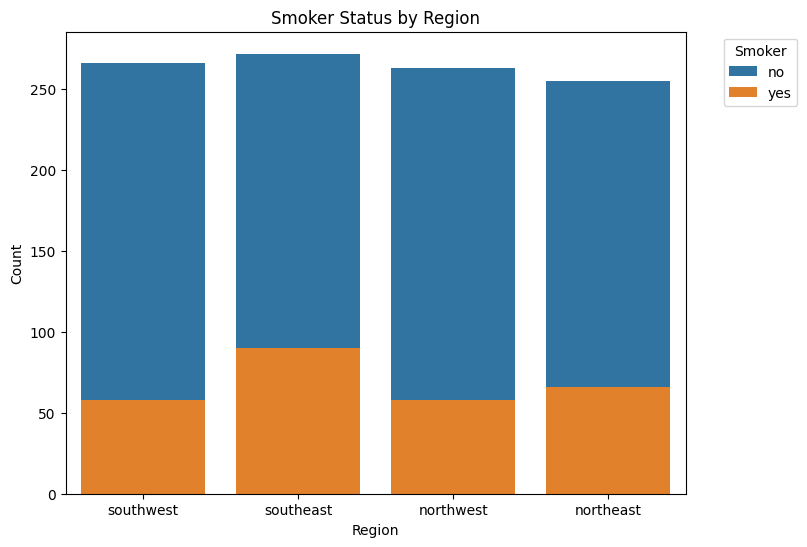

In [22]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="region", hue="smoker", dodge=False, order=df["region"].unique(), hue_order=["no", "yes"])  # Ensure "yes" is in front
plt.title("Smoker Status by Region")
plt.xlabel("Region")
plt.ylabel("Count")

# Move legend outside
plt.legend(title="Smoker", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()



In [23]:
# Importing the necessary libraries
import numpy as np
import scipy.stats as stats

# Create a contingency table
contingency_table = pd.crosstab(df["region"], df["smoker"])

# Perform Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Compute Cramér's V
n = contingency_table.sum().sum()  # Total sample size
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# Display Results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

# Interpretation
if cramers_v < 0.1:
    strength = "Very Weak"
elif cramers_v < 0.2:
    strength = "Weak"
elif cramers_v < 0.3:
    strength = "Moderate"
elif cramers_v < 0.4:
    strength = "Relatively Strong"
else:
    strength = "Strong"

print(f"Strength of Association: {strength}")


Chi-Square Statistic: 6.7380
P-value: 0.0807
Cramér's V: 0.0712
Strength of Association: Very Weak


# Part II: Parametric Statistical Testing

In [24]:
# Importing the necessary libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder


In [25]:
anova_model = smf.ols("bmi ~ C(region)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)


                 sum_sq      df          F        PR(>F)
C(region)   4054.510281     3.0  39.406872  2.159954e-24
Residual   45408.083210  1324.0        NaN           NaN


In [26]:
# Group BMI values by Region
regions = df["region"].unique()
bmi = [df[df["region"] == region]["bmi"] for region in regions]

# Perform ANOVA
stat, p = stats.f_oneway(*bmi)

print(f"ANOVA Test Statistic: {stat:.4f}")
print(f"p-value: {p:.4f}")

# Interpretation
if p < 0.05:
    print("Reject the null hypothesis: BMI differs significantly across regions.")
else:
    print("Fail to reject the null hypothesis: No significant difference in BMI across regions.")

ANOVA Test Statistic: 39.4069
p-value: 0.0000
Reject the null hypothesis: BMI differs significantly across regions.


# Part III: Nonparametric Statistical Testing

In [ ]:
# Nonparametric testing: Mann-Whitney U

# Split the Charges data based on Smoker status
charges_smokers = df[df['smoker'] == 'yes']['charges']
charges_nonsmokers = df[df['smoker'] == 'no']['charges']

# Perform the Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(charges_smokers, charges_nonsmokers, alternative='two-sided')

# Print results
print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in charges between smokers and non-smokers.")
else:
    print("Fail to reject the null hypothesis: No significant difference in charges between smokers and non-smokers.")

Mann-Whitney U Test Statistic: 279939.0
P-value: 4.5854915954998375e-129
Reject the null hypothesis: There is a significant difference in charges between smokers and non-smokers.
